In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from numpy.random import binomial
from scipy.stats import ks_2samp, chi2_contingency, norm, probplot, shapiro, normaltest
import statsmodels.api as sm

In [ ]:
df=pd.read_csv('data_ab.csv')
df

,user_id,timestamp,group,landing_page,converted
0,851104,2025-01-21 22:11:48.556739,control,old_page,0
1,804228,2025-01-12 08:01:45.159739,control,old_page,0
2,661590,2025-01-11 16:55:06.154213,treatment,new_page,0
3,853541,2025-01-08 18:28:03.143765,treatment,new_page,0
4,864975,2025-01-21 01:52:26.210827,control,old_page,1
...,...,...,...,...,...
294473,751197,2025-01-03 22:28:38.630509,control,old_page,0
294474,945152,2025-01-12 00:51:57.078372,control,old_page,0
294475,734608,2025-01-22 11:45:03.439544,control,old_page,0
294476,697314,2025-01-15 01:20:28.957438,control,old_page,0


# Раздел 1: EDA

In [ ]:
from datetime import datetime
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 294478 entries, 0 to 294477
Data columns (total 5 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   user_id       294478 non-null  int64 
 1   timestamp     294478 non-null  object
 2   group         294478 non-null  object
 3   landing_page  294478 non-null  object
 4   converted     294478 non-null  int64 
dtypes: int64(2), object(3)
memory usage: 11.2+ MB


преобразуем столбец timestamp из object в datetime

In [ ]:
df['timestamp'] = pd.to_datetime(df['timestamp'])
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 294478 entries, 0 to 294477
Data columns (total 5 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   user_id       294478 non-null  int64         
 1   timestamp     294478 non-null  datetime64[ns]
 2   group         294478 non-null  object        
 3   landing_page  294478 non-null  object        
 4   converted     294478 non-null  int64         
dtypes: datetime64[ns](1), int64(2), object(2)
memory usage: 11.2+ MB


Посмотрим, за сколько дней собраны данные

In [ ]:
df['date_only'] = df['timestamp'].dt.date
df['hour'] = df['timestamp'].dt.hour
len(df['date_only'].unique())

23

посмотрим, что это за дни

In [ ]:
df['date_only'].sort_values().unique()

array([datetime.date(2025, 1, 2), datetime.date(2025, 1, 3),
       datetime.date(2025, 1, 4), datetime.date(2025, 1, 5),
       datetime.date(2025, 1, 6), datetime.date(2025, 1, 7),
       datetime.date(2025, 1, 8), datetime.date(2025, 1, 9),
       datetime.date(2025, 1, 10), datetime.date(2025, 1, 11),
       datetime.date(2025, 1, 12), datetime.date(2025, 1, 13),
       datetime.date(2025, 1, 14), datetime.date(2025, 1, 15),
       datetime.date(2025, 1, 16), datetime.date(2025, 1, 17),
       datetime.date(2025, 1, 18), datetime.date(2025, 1, 19),
       datetime.date(2025, 1, 20), datetime.date(2025, 1, 21),
       datetime.date(2025, 1, 22), datetime.date(2025, 1, 23),
       datetime.date(2025, 1, 24)], dtype=object)

данные с 2 по 24 января 2025 года

Посмотрим, сколько данных по каждому из дней

<Axes: xlabel='date_only', ylabel='Count'>

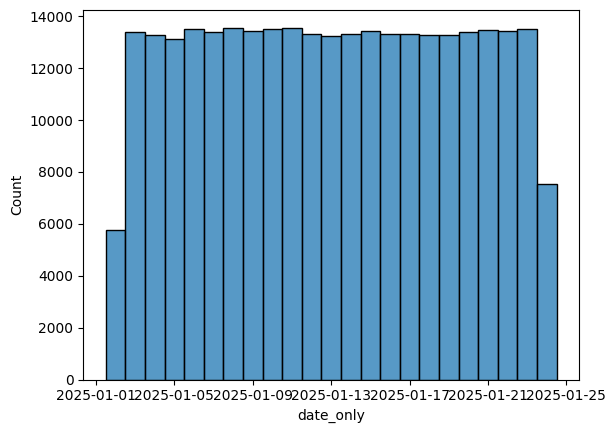

In [ ]:
sns.histplot(df['date_only'],bins=23)


похоже, что в 1 и последний день данные собраны не за весь день

Отсортируем данные по времени

In [ ]:
df = df.sort_values('timestamp')
df

,user_id,timestamp,group,landing_page,converted,date_only,hour
131228,922696,2025-01-02 13:42:05.378582,treatment,new_page,0,2025-01-02,13
184884,781507,2025-01-02 13:42:15.234051,control,old_page,0,2025-01-02,13
83878,737319,2025-01-02 13:42:21.786186,control,old_page,0,2025-01-02,13
102717,818377,2025-01-02 13:42:26.640581,treatment,new_page,0,2025-01-02,13
158789,725857,2025-01-02 13:42:27.851110,treatment,new_page,0,2025-01-02,13
...,...,...,...,...,...,...,...
153305,851645,2025-01-24 13:41:18.869978,treatment,old_page,0,2025-01-24,13
47535,808330,2025-01-24 13:41:19.152664,control,old_page,0,2025-01-24,13
157787,843121,2025-01-24 13:41:44.097174,treatment,new_page,0,2025-01-24,13
179072,836373,2025-01-24 13:41:52.604673,control,old_page,0,2025-01-24,13


Проверим гипотезу о том, что в крайние даты записи были не за весь день.



In [ ]:
day_first = df[df['timestamp'].dt.date==pd.Timestamp('2025-01-02').date()]
day_last = df[df['timestamp'].dt.date==pd.Timestamp('2025-01-24').date()]
print(day_first, day_last)

        user_id                  timestamp      group landing_page  converted  \
131228   922696 2025-01-02 13:42:05.378582  treatment     new_page          0   
184884   781507 2025-01-02 13:42:15.234051    control     old_page          0   
83878    737319 2025-01-02 13:42:21.786186    control     old_page          0   
102717   818377 2025-01-02 13:42:26.640581  treatment     new_page          0   
158789   725857 2025-01-02 13:42:27.851110  treatment     new_page          0   
...         ...                        ...        ...          ...        ...   
263222   898056 2025-01-02 23:59:18.956854  treatment     new_page          0   
83723    863102 2025-01-02 23:59:38.761977    control     old_page          1   
260700   855867 2025-01-02 23:59:49.019117  treatment     new_page          0   
137939   898006 2025-01-02 23:59:50.660581    control     old_page          0   
164605   728979 2025-01-02 23:59:55.515685    control     old_page          0   

         date_only  hour  


In [ ]:
print(day_first.timestamp.sort_values().head(1))
print(day_last.timestamp.sort_values(ascending=False).head(1))

131228   2025-01-02 13:42:05.378582
Name: timestamp, dtype: datetime64[ns]
193652   2025-01-24 13:41:54.460509
Name: timestamp, dtype: datetime64[ns]


Вывод: данные брались ровно за 22 суток и сбор информации начался 2025-01-02 в 13:42:05 и продлился до 13:41:55 2025-01-24.

можем так же рассмотреть число записей по часам

/tmp/ipython-input-496081543.py:2: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  df['date_hour'] = df['timestamp'].dt.floor('H')


<Axes: xlabel='date_hour', ylabel='Count'>

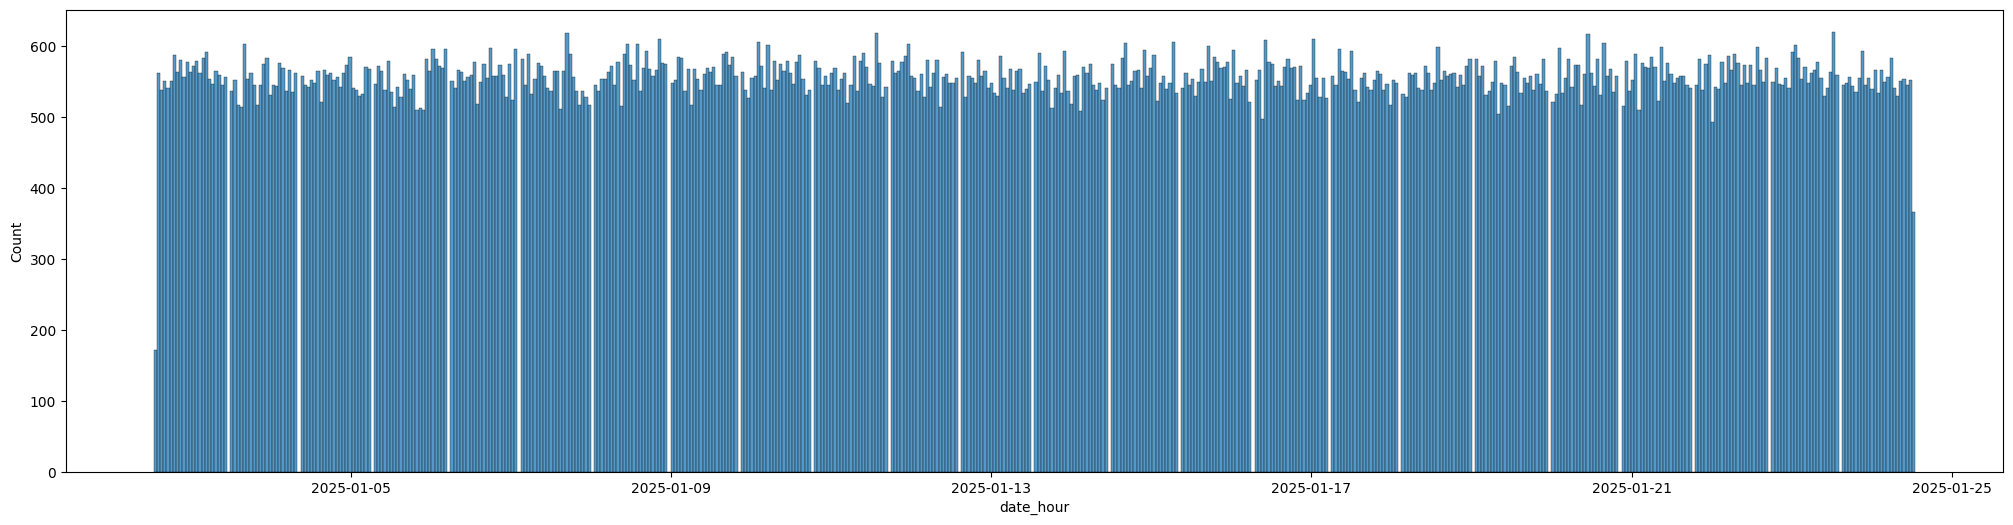

In [ ]:

fig, ax = plt.subplots(figsize=(25, 6))
df['date_hour'] = df['timestamp'].dt.floor('H')
sns.histplot(df['date_hour'],bins=24*23)


В нашем датасете есть 2 группы: контрольная и тестовая, но в датасете так же есть параметр, который указывает, какая версия страницы была показана тому или иному человеку. В А/В тестах контрольной выборке зачастую показывают продукт без изменений, а тестовой - с. Проверим, так ли у нас

In [ ]:
df.groupby('group').landing_page.value_counts()

group      landing_page
control    old_page        145274
           new_page          1928
treatment  new_page        145311
           old_page          1965
Name: count, dtype: int64

Видим, что у нас встречаются странные случаи, когда людям из контрольной выборки показывается новая страница, а людям из тестовой - старая

Второй случай может быть А/А тестом, но тогда он должен запускаться в самом начале - перед всеми остальными. Проверим

In [ ]:
aa_df = df[
    ((df['group'] == 'control') & (df['landing_page'] == 'new_page')) |
    ((df['group'] == 'treatment') & (df['landing_page'] == 'old_page'))
].copy()

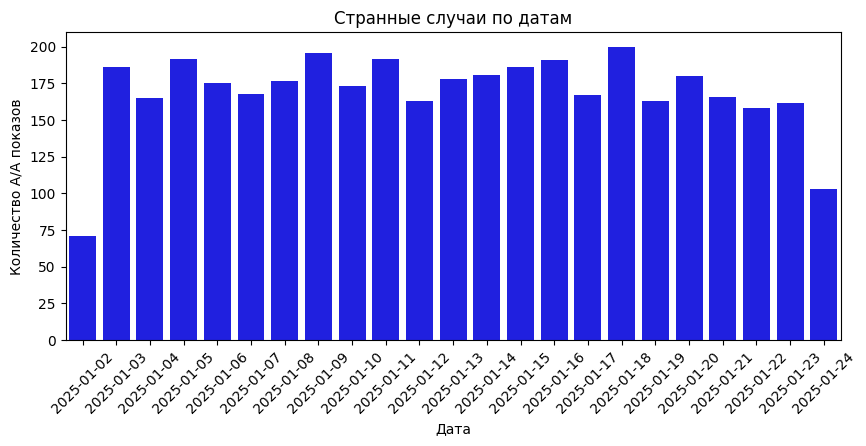

In [ ]:
plt.figure(figsize=(10,4))
sns.countplot(data=aa_df, x="date_only", color="blue")
plt.title("Странные случаи по датам")
plt.xticks(rotation=45)
plt.xlabel("Дата")
plt.ylabel("Количество A/A показов")
plt.show()

Видим, что число странных случаев не превышает 200 за день. Посмотрим еще каждый случай (тестовой - старый / контрольной - новый) по отдельности

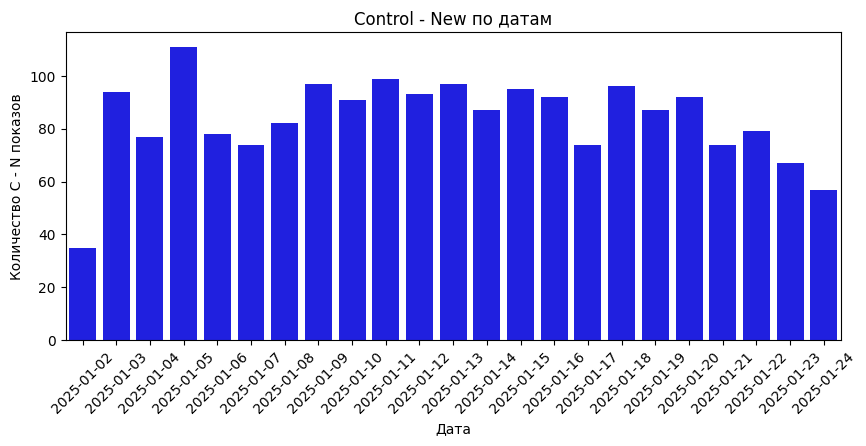

In [ ]:
dfCN = df[((df['group'] == 'control') & (df['landing_page'] == 'new_page'))]
plt.figure(figsize=(10,4))
sns.countplot(data=dfCN, x="date_only", color="blue")
plt.title("Control - New по датам")
plt.xticks(rotation=45)
plt.xlabel("Дата")
plt.ylabel("Количество C - N показов")
plt.show()

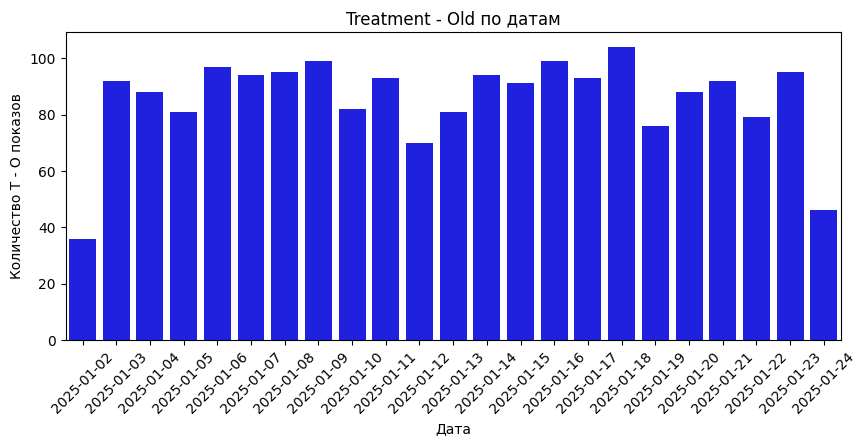

In [ ]:
dfTO = df[((df['group'] == 'treatment') & (df['landing_page'] == 'old_page'))]
plt.figure(figsize=(10,4))
sns.countplot(data=dfTO, x="date_only", color="blue")
plt.title("Treatment - Old по датам")
plt.xticks(rotation=45)
plt.xlabel("Дата")
plt.ylabel("Количество T - O показов")
plt.show()

Не выглядит как А/А тест, потому что он проводится до запуска А/В тестирования, а здесь мы наблюдаем, можно сказать, хаотичную картину.

В таком случае мы до конца не знаем, как интерпретировать случаи, где контрольной выборке показали новую страницу/тестовой старую. Нам лучше удалить эти ошибочные значения. Но для этого нужно убедиться, что они являются небольшой частью датасета

In [ ]:
aa_df.shape[0]/df.shape[0]

0.013220002852505111

странные данные занимают всего 1,3% поэтому можем дропнуть их

In [ ]:
df = df[
    ((df['group'] == 'control') & (df['landing_page'] == 'old_page')) |
    ((df['group'] == 'treatment') & (df['landing_page'] == 'new_page'))
]
df

,user_id,timestamp,group,landing_page,converted,date_only,hour,date_hour
131228,922696,2025-01-02 13:42:05.378582,treatment,new_page,0,2025-01-02,13,2025-01-02 13:00:00
184884,781507,2025-01-02 13:42:15.234051,control,old_page,0,2025-01-02,13,2025-01-02 13:00:00
83878,737319,2025-01-02 13:42:21.786186,control,old_page,0,2025-01-02,13,2025-01-02 13:00:00
102717,818377,2025-01-02 13:42:26.640581,treatment,new_page,0,2025-01-02,13,2025-01-02 13:00:00
158789,725857,2025-01-02 13:42:27.851110,treatment,new_page,0,2025-01-02,13,2025-01-02 13:00:00
...,...,...,...,...,...,...,...,...
158814,799244,2025-01-24 13:41:15.325359,treatment,new_page,0,2025-01-24,13,2025-01-24 13:00:00
47535,808330,2025-01-24 13:41:19.152664,control,old_page,0,2025-01-24,13,2025-01-24 13:00:00
157787,843121,2025-01-24 13:41:44.097174,treatment,new_page,0,2025-01-24,13,2025-01-24 13:00:00
179072,836373,2025-01-24 13:41:52.604673,control,old_page,0,2025-01-24,13,2025-01-24 13:00:00


проверим, нет ли других странных ситуаций, например, когда человеку показали одну и ту же страницу 2 раза

In [ ]:
df["user_id"].value_counts()

,count
user_id,
773192,2
867327,1
762358,1
697722,1
738870,1
...,...
799597,1
719701,1
773788,1


Посмотрим, что это за показы


In [ ]:
df[df.user_id == 773192]

,user_id,timestamp,group,landing_page,converted,date_only,hour,date_hour
1899,773192,2025-01-09 05:37:58.781806,treatment,new_page,0,2025-01-09,5,2025-01-09 05:00:00
2893,773192,2025-01-14 02:55:59.590927,treatment,new_page,0,2025-01-14,2,2025-01-14 02:00:00


два показа в разные дни в разное время - похоже на ошибку, так что можем удалить 1 из 2х

In [ ]:
df = df.drop_duplicates('user_id')
df

,user_id,timestamp,group,landing_page,converted,date_only,hour,date_hour
131228,922696,2025-01-02 13:42:05.378582,treatment,new_page,0,2025-01-02,13,2025-01-02 13:00:00
184884,781507,2025-01-02 13:42:15.234051,control,old_page,0,2025-01-02,13,2025-01-02 13:00:00
83878,737319,2025-01-02 13:42:21.786186,control,old_page,0,2025-01-02,13,2025-01-02 13:00:00
102717,818377,2025-01-02 13:42:26.640581,treatment,new_page,0,2025-01-02,13,2025-01-02 13:00:00
158789,725857,2025-01-02 13:42:27.851110,treatment,new_page,0,2025-01-02,13,2025-01-02 13:00:00
...,...,...,...,...,...,...,...,...
158814,799244,2025-01-24 13:41:15.325359,treatment,new_page,0,2025-01-24,13,2025-01-24 13:00:00
47535,808330,2025-01-24 13:41:19.152664,control,old_page,0,2025-01-24,13,2025-01-24 13:00:00
157787,843121,2025-01-24 13:41:44.097174,treatment,new_page,0,2025-01-24,13,2025-01-24 13:00:00
179072,836373,2025-01-24 13:41:52.604673,control,old_page,0,2025-01-24,13,2025-01-24 13:00:00


Теперь наши данные чистые - без пропусков, дубликатов и странных данных

Подготовка данных по дням и часам

In [ ]:
hourly_by_day = df.groupby(['date_only', 'hour']).agg(
    conversion_rate=('converted', 'mean')
).reset_index()

Каждый день будем изображать отдельной линией, а также проведем линю среднего

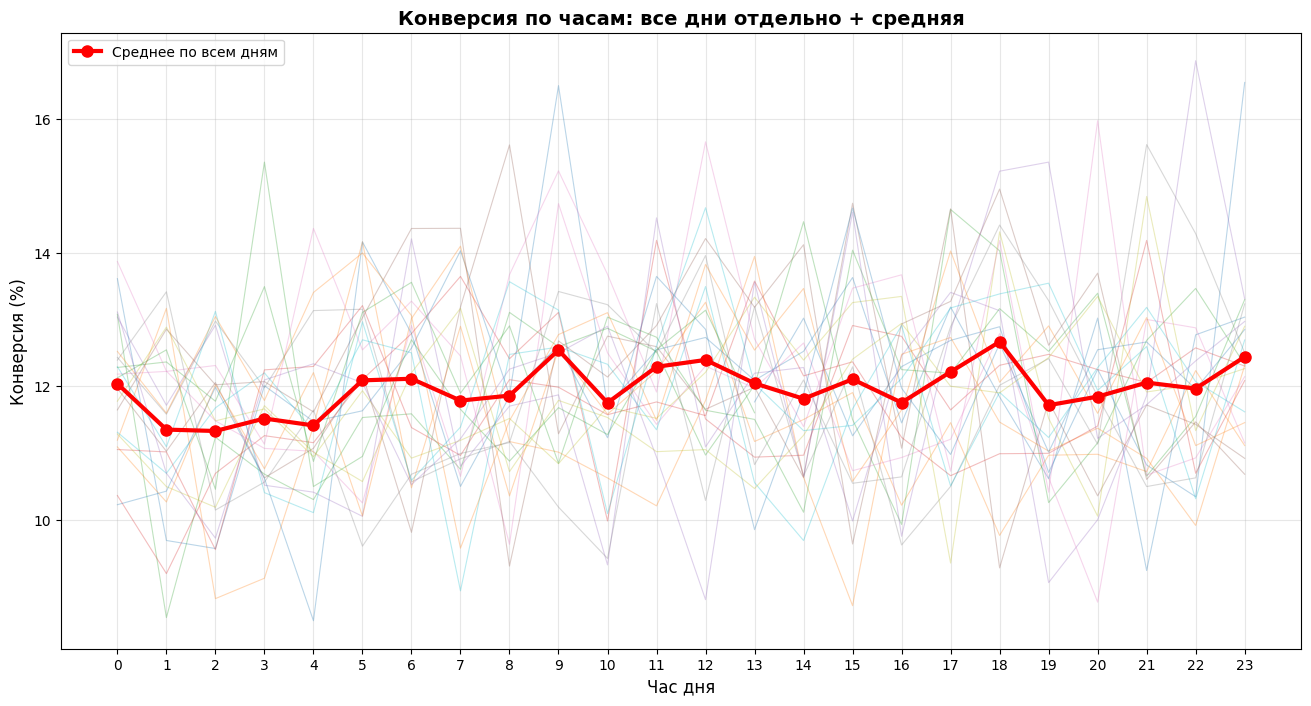

In [ ]:
plt.figure(figsize=(16, 8))

for date in hourly_by_day['date_only'].unique():
    day_data = hourly_by_day[hourly_by_day['date_only'] == date]
    plt.plot(day_data['hour'], day_data['conversion_rate'] * 100,
             alpha=0.3, linewidth=0.8)

hourly_avg = hourly_by_day.groupby('hour')['conversion_rate'].mean().reset_index()
plt.plot(hourly_avg['hour'], hourly_avg['conversion_rate'] * 100,
linewidth=3, color='red', marker='o', markersize=8,
         label='Среднее по всем дням')

plt.title('Конверсия по часам: все дни отдельно + средняя', fontsize=14, fontweight='bold')
plt.xlabel('Час дня', fontsize=12)
plt.ylabel('Конверсия (%)', fontsize=12)
plt.xticks(range(0, 24))
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

# Анализ чувствительности

можем нагляднее посмотреть на конверсию по дням и часа с помощью тепловой карты

Заполняем NaN нулями

Максимальное значение: 0.1687612208258528
Минимальное значение: 0.08487084870848709


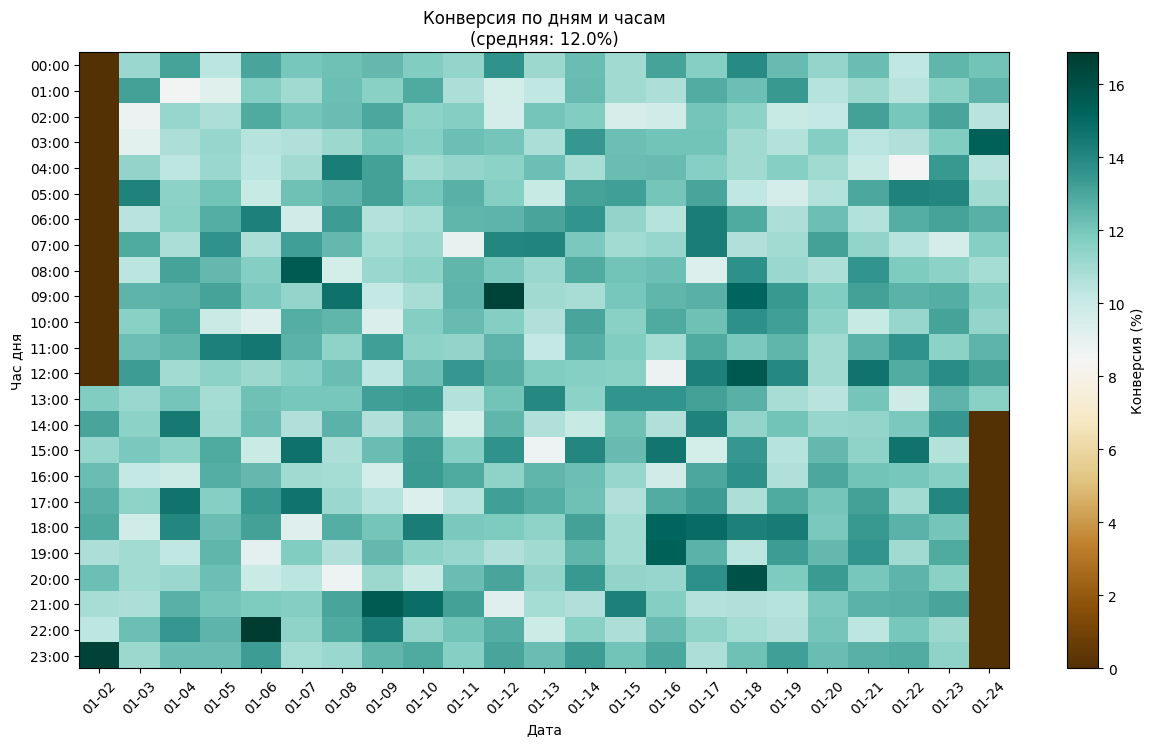

In [ ]:
pivot = df.groupby(['date_only', 'hour'])['converted'].mean().unstack()

pivot_filled = pivot.fillna(0)

print("Максимальное значение:", pivot_filled.values.max())
print("Минимальное значение:", pivot_filled[(~np.isnan(pivot_filled)) & (pivot_filled > 0)].min().min())

plt.figure(figsize=(15, 8))
values = pivot_filled.values.T * 100

plt.imshow(values, aspect='auto', cmap='BrBG', vmin=0)
plt.colorbar(label='Конверсия (%)')

plt.yticks(range(24), [f'{h:02d}:00' for h in range(24)])
plt.xticks(range(len(pivot_filled)),
           [d.strftime('%m-%d') for d in pivot_filled.index],
           rotation=45)

plt.xlabel('Дата')
plt.ylabel('Час дня')
plt.title(f'Конверсия по дням и часам\n(средняя: {df["converted"].mean()*100:.1f}%)')
plt.show()

Тепловая карта для control

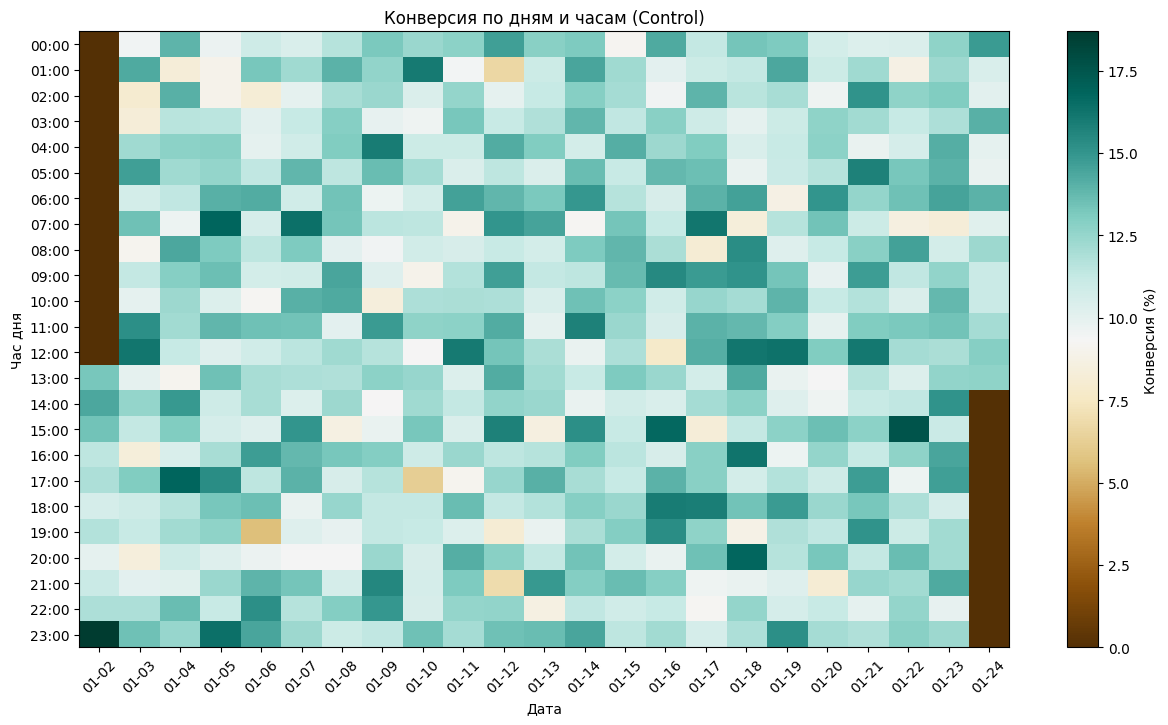

In [ ]:
pivot_control = df[df['group'] == 'control'].groupby(['date_only', 'hour'])['converted'].mean().unstack().fillna(0)
plt.figure(figsize=(15, 8))
plt.imshow(pivot_control.values.T * 100, aspect='auto', cmap='BrBG', vmin=0)
plt.colorbar(label='Конверсия (%)')
plt.yticks(range(24), [f'{h:02d}:00' for h in range(24)])
plt.xticks(range(len(pivot_control)), [d.strftime('%m-%d') for d in pivot_control.index], rotation=45)
plt.xlabel('Дата')
plt.ylabel('Час дня')
plt.title('Конверсия по дням и часам (Control)')
plt.show()


Тепловая карта для treatment

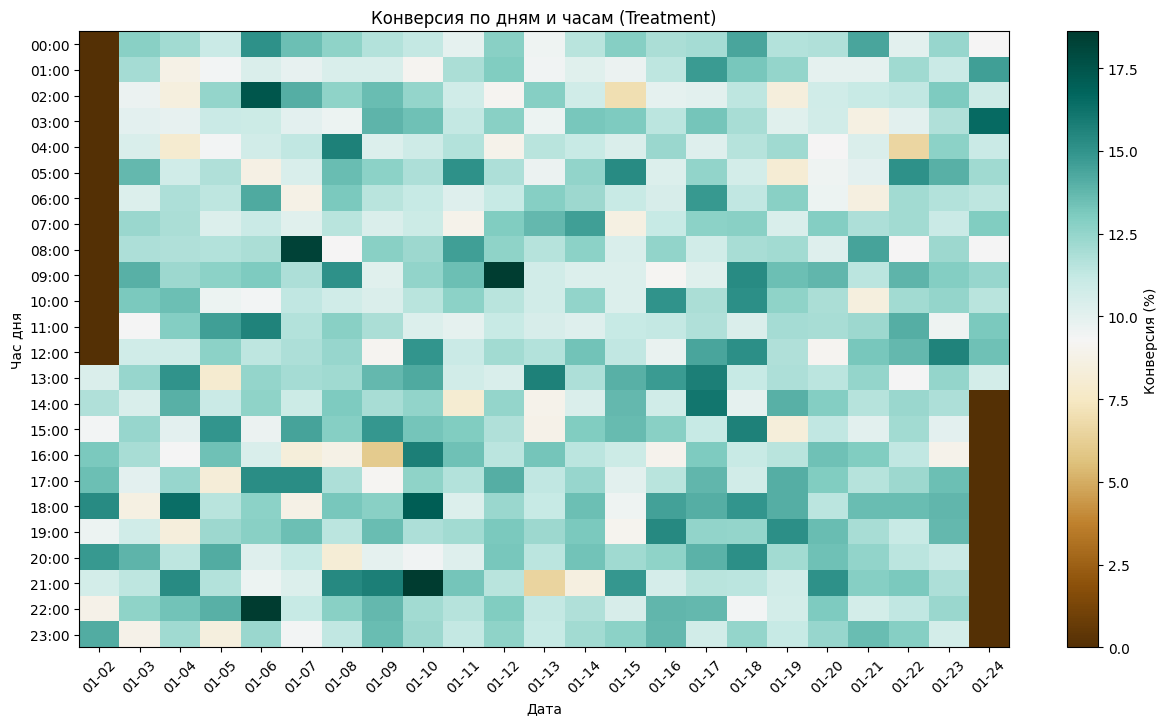

In [ ]:
pivot_treatment = df[df['group'] == 'treatment'].groupby(['date_only', 'hour'])['converted'].mean().unstack().fillna(0)
plt.figure(figsize=(15, 8))
plt.imshow(pivot_treatment.values.T * 100, aspect='auto', cmap='BrBG', vmin=0)
plt.colorbar(label='Конверсия (%)')
plt.yticks(range(24), [f'{h:02d}:00' for h in range(24)])
plt.xticks(range(len(pivot_treatment)), [d.strftime('%m-%d') for d in pivot_treatment.index], rotation=45)
plt.xlabel('Дата')
plt.ylabel('Час дня')
plt.title('Конверсия по дням и часам (Treatment)')
plt.show()

Можем посмотреть на распределение визитов по часу дня для каждойй группы (а зачем? чтобы показать, что было +- равноценно, т.е. А/В тест справедлив?)

In [ ]:
time_group_table = pd.crosstab(df['hour'], df['group'])
chi2_time, p_time, dof_time, expected_time = chi2_contingency(time_group_table)

print("Хи-квадрат: ", chi2_time, "p-value ",  p_time)
dof_time

Хи-квадрат:  37.470439374411896 p-value  0.02900771459550439


23

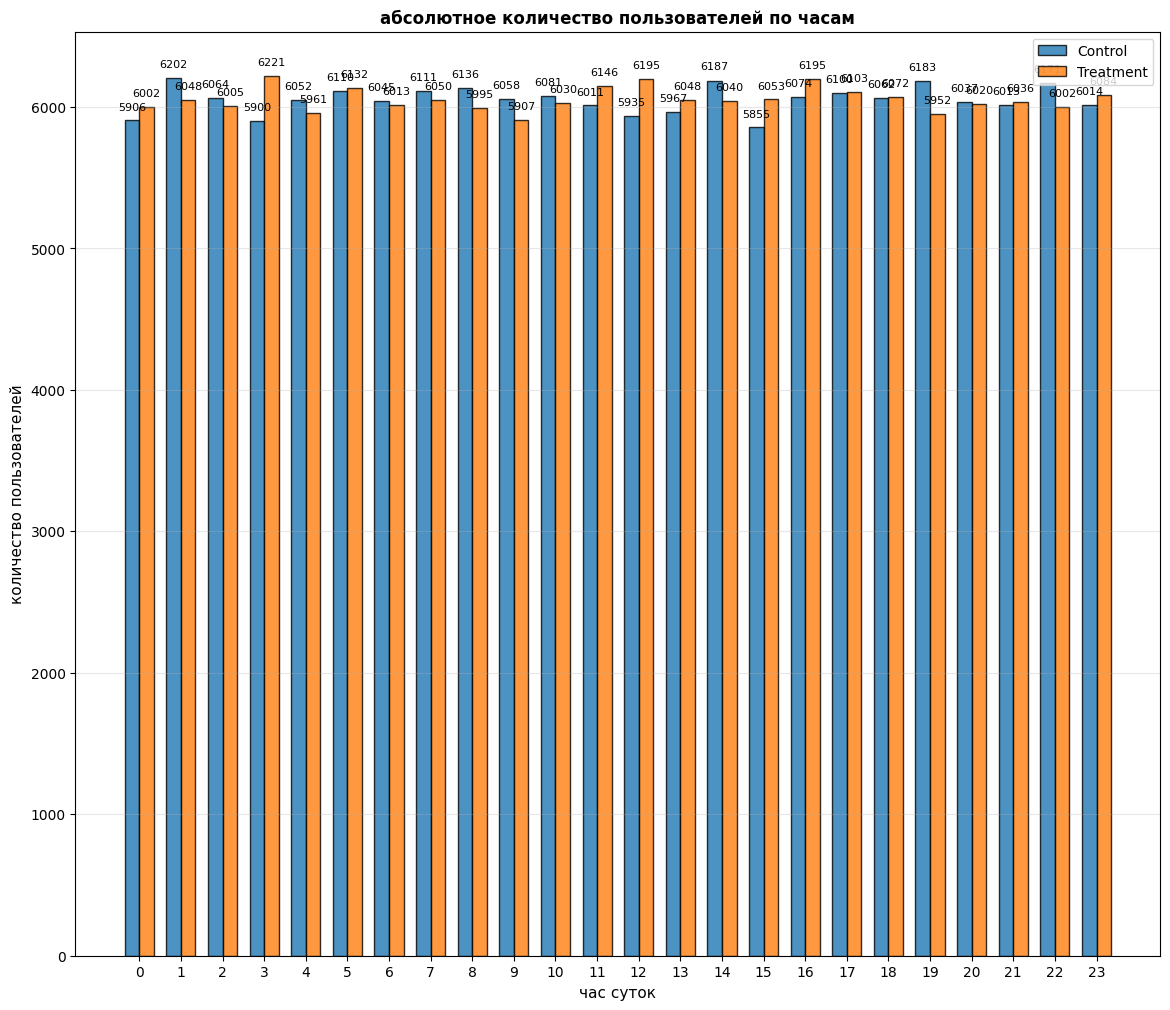

In [ ]:
hour_distribution = pd.crosstab(df['hour'], df['group'])
hour_distribution = hour_distribution.sort_index()

hour_distribution['ratio_T_C'] = hour_distribution['treatment'] / hour_distribution['control']
hour_distribution['pct_diff'] = ((hour_distribution['treatment'] - hour_distribution['control']) /
                                 (hour_distribution['treatment'] + hour_distribution['control']) * 100)

fig, ax = plt.subplots(figsize=(14, 12))

hours = hour_distribution.index
x = np.arange(len(hours))
width = 0.35

bars_control = ax.bar(x - width/2, hour_distribution['control'], width,
                      label='Control', alpha=0.8, color='#1f77b4', edgecolor='black')
bars_treatment = ax.bar(x + width/2, hour_distribution['treatment'], width,
                        label='Treatment', alpha=0.8, color='#ff7f0e', edgecolor='black')

problem_mask = (hour_distribution['ratio_T_C'] < 0.8) | (hour_distribution['ratio_T_C'] > 1.2)
for i, is_problem in enumerate(problem_mask):
    if is_problem:
        ax.axvspan(i - 0.5, i + 0.5, alpha=0.2, color='red', zorder=0)

ax.set_xlabel('час суток', fontsize=11)
ax.set_ylabel('количество пользователей', fontsize=11)
ax.set_title('абсолютное количество пользователей по часам', fontsize=12, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(hours)
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

# Добавляем значения на столбцы
def autolabel(bars, ax):
    for bar in bars:
        height = bar.get_height()
        if height > 0:
            ax.text(bar.get_x() + bar.get_width()/2., height + max(height*0.01, 5),
                    int(height), ha='center', va='bottom', fontsize=8)

autolabel(bars_control, ax)
autolabel(bars_treatment, ax)
plt.show()

Хи квадрат тест работает плохо на больших данных, его чувствительность к ошибкам становится очень высокой, мощность теста слишком высокая для выбранной предметной области. Следовательно, стоит выбрать тест, который будет более подходящим, например, тест Колмогорова Смирнова, который сравнивает сами распределения.

In [ ]:
control_hours = df[df['group'] == 'control']['hour']
treatment_hours = df[df['group'] == 'treatment']['hour']

ks_stat, ks_p = ks_2samp(control_hours, treatment_hours)
print("p-value: ", ks_p)

p-value:  0.8430165548624942


In [ ]:
hour_table = pd.crosstab(df['hour'], df['group'])

ratios = hour_table['treatment'] / hour_table['control']
rmse = np.sqrt(np.mean((ratios - 1)**2))
mean_abs_dev = np.mean(np.abs(ratios - 1))

print("rmse отклонений в процентах: ", rmse*100)
print("среднее абсолютное отклонение в процентах: ", 100*mean_abs_dev)

rmse отклонений в процентах:  2.285963459502359
среднее абсолютное отклонение в процентах:  1.824723739148459


Рассмотрим конверсию по группам

In [ ]:
group_conversion = df.groupby('group').agg(
    visitors=('user_id', 'count'),
    conversions=('converted', 'sum'),
    conversion_rate=('converted', 'mean')
).reset_index()
group_conversion

,group,visitors,conversions,conversion_rate
0,control,145274,17489,0.120386
1,treatment,145310,17264,0.118808


Посмотрим на конверсию по группам и разницу конверсий по часам наглядно

In [ ]:
control_df = df[df['group'] == 'control']
treatment_df = df[df['group'] == 'treatment']

control_conv = control_df['converted'].mean()
treatment_conv = treatment_df['converted'].mean()
observed_diff = treatment_conv - control_conv

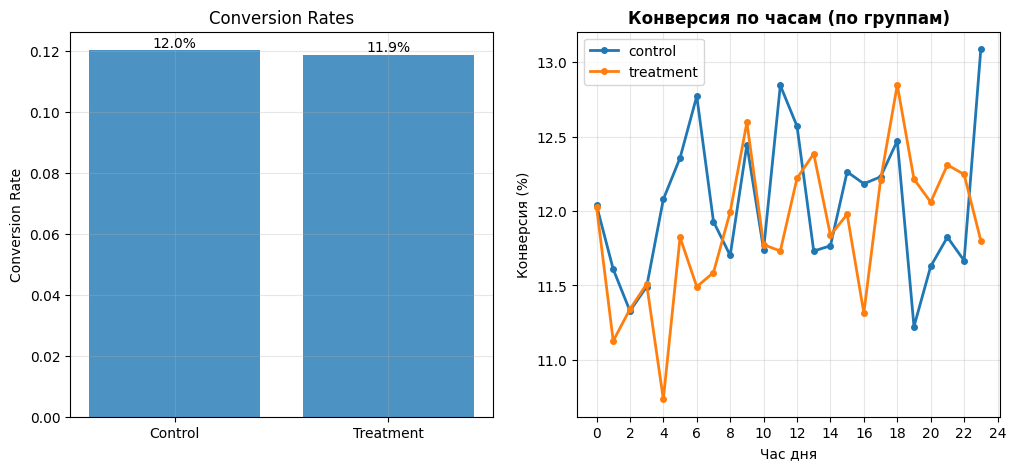

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

ax1.bar(['Control', 'Treatment'],
        [control_conv, treatment_conv],
        alpha=0.8)

for i, conv in enumerate([control_conv, treatment_conv]):
    ax1.text(i, conv + 0.001, f'{conv:.1%}', ha='center')


ax1.set_ylabel('Conversion Rate')
ax1.set_title('Conversion Rates')
ax1.grid(True, alpha=0.3)

hourly_by_group = df.groupby(['hour', 'group'])['converted'].mean().unstack() * 100

for group in hourly_by_group.columns:
    ax2.plot(hourly_by_group.index, hourly_by_group[group],
                 marker='o', linewidth=2, markersize=4, label=group)

ax2.set_title('Конверсия по часам (по группам)', fontweight='bold')
ax2.set_xlabel('Час дня')
ax2.set_ylabel('Конверсия (%)')
ax2.set_xticks(range(0, 25, 2))
ax2.grid(True, alpha=0.3)
ax2.legend()

plt.show()

можем еще посмотреть на разницу конверсий по дням

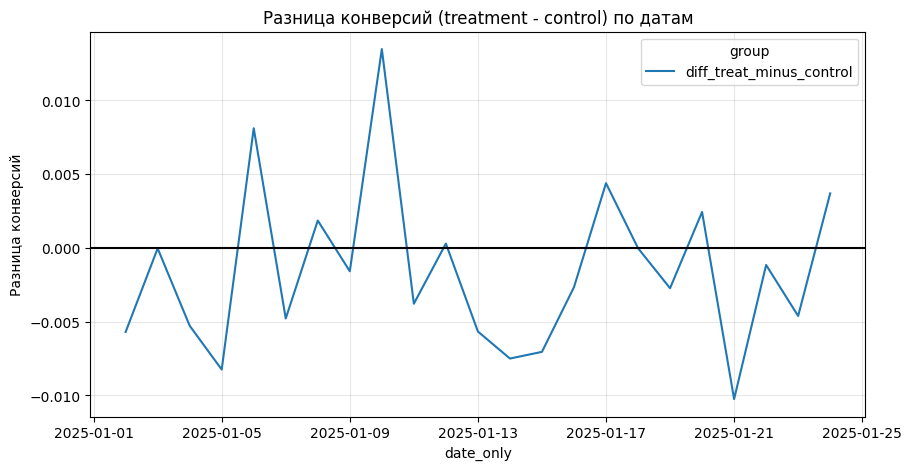

In [ ]:
conv_by_day = (
    df.groupby(["date_only", "group"])["converted"].mean().unstack()
)

conv_by_day["diff_treat_minus_control"] = (
    conv_by_day["treatment"] - conv_by_day["control"]
)

conv_by_day[["diff_treat_minus_control"]].plot(figsize=(10, 5))
plt.axhline(0, color='black')
plt.title("Разница конверсий (treatment - control) по датам")
plt.ylabel("Разница конверсий")
plt.grid(alpha=0.3)
plt.show()

Отсюда можно сделать выводы.
+ Колчество участников по группам примерно идентичное, разницей можно пренебречь и считать выборки сбалансированными.
+ Процент конверсий в группах практически не различается, что говорит о необходимости более детального анализа. Здесь можно уже основательно выдвинуть нулевую гипотезу - новая страница не влияет на процент конверсий.

# Раздел 2


                                                Гипотезы.

В результате A/B теста необходимо выяснить, стоит ли внедрять новый лэндинг или лучше оставить старый. Метрикой, по которой мы будем оценивать успешность типа страницы, будет уровень конверсии: процент пользователей с параметром
                      
                                                converted = 1

в рамках одной группы(control или treatment)от общего количества пользователей рассматриваемой группы.

Нулевая гипотеза - новый тип лэндинга не лучше старого. Если нам не удастся отвергнуть нулевую гипотезу при заданном уровне значимости 5%, у нас не будет статистических оснований считать, что новый лэндинг лучше. Бизнес-решение об изменениях в этом случае должно приниматься с осторожностью, учитывая стоимость внедрения и потенциальные риски.

Альтернативная гипотеза - новый тип лэндинга показал себя лучше, чем старый. Если мы отвергнем нулевую гипотезу в пользу альтернативной, это будет статистическим свидетельством в пользу того, что новый лэндинг приводит к более высокой конверсии.

Выбор уровня значимости в 5% обусловлен прецедентом использования: зачастую в бизнесе берётся именно такое значение. Выборка достаточно большая, что говорит о масштабности компании, для которой проводилось A/B тестирование, следовательно цена ошибки 1-го рода более существенной для бизнеса (получение ложноположительных результатов в пользу новой страницы, когда на самом деле она "хуже" старой) будет существенна(можем потерять клиентов + мы не знаем каковы затраты на доработку новой страницы ), но не катастрофична.





In [ ]:
cr_new = cr_old = len(df[df['converted']==1])/len(df)

group_control = len(df[df['group']=='control'])
group_treatment = len(df[df['group']=='treatment'])
print(cr_new, cr_old)
print(group_control, group_treatment)

0.11959708724499628 0.11959708724499628
145274 145310


Мы имеем массу уникальных и независимых случайных событий, характера "конвертировался/не конвертировался" для каждого из пользователей, тогда совокупность таких событий, где каждое распределено по Бернулли с параметром p = cr_new = cr_old (по предположению), подчинена биномиальному распределению. То есть количеству успехов из n незавимимых эксперементов, где вероятность успеха в каждом из них равна p.



In [ ]:
np.random.seed(1488)
new_page_experiment = binomial(group_treatment, cr_new)/group_treatment
new_page_experiment

0.1210446631339894

In [ ]:
np.random.seed(1488)
old_page_experiment = binomial(group_control, cr_old)/group_control
old_page_experiment

0.12104712474358797

In [ ]:
new_page_experiment - old_page_experiment

-2.4616095985752207e-06

Основываясь на ИТМЛ, где - наши выборки независимые, одинаково распределённые, можем рассматривать распределения new_page_experiment и old_page_experiment как нормально распределённые. распределение differences также является нормальным.

То есть мы увеличиваем количество экспериментов, где считаем различия в показателях конверсии.
В исходных данных мы имели только одну реализацию случайного эксперимента, чего явно не достаточно для справедливой оценки успешности.

In [ ]:
np.random.seed(1488)
new_page_experiment = binomial(group_treatment, cr_new, 10**5)/group_treatment
old_page_experiment = binomial(group_control, cr_old, 10**5)/group_control
differences = new_page_experiment - old_page_experiment
differences

array([ 2.04195102e-03,  4.03948885e-04,  5.97512101e-05, ...,
       -2.01814943e-04,  2.88864742e-03, -8.41824248e-04])

(array([6.0000e+01, 8.2000e+02, 5.6770e+03, 1.9642e+04, 3.3058e+04,
        2.7372e+04, 1.0930e+04, 2.2300e+03, 1.9800e+02, 1.3000e+01]),
 array([-0.00494396, -0.00389849, -0.00285302, -0.00180755, -0.00076208,
         0.0002834 ,  0.00132887,  0.00237434,  0.00341981,  0.00446529,
         0.00551076]),
 <BarContainer object of 10 artists>)

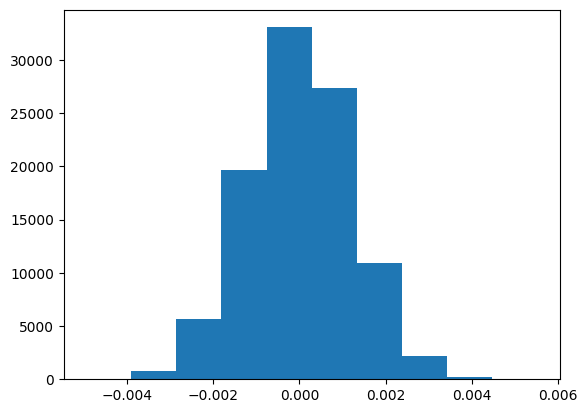

In [ ]:
plt.hist(differences)

In [ ]:
converted_new = df[(df['converted']==1) & (df['landing_page'] == 'new_page')]
converted_old = df[(df['converted']==1) & (df['landing_page'] == 'old_page')]
general_differences = len(converted_new)/len(df[df['landing_page'] == "new_page"]) - len(converted_old)/len(df[df['landing_page'] == "old_page"])
general_differences

-0.0015782389853555567

Если сравнить значения равновероятных, распределённых нормально уровней конверсии(по нулевой гипотизе) с реальным уровнем конверсии, представленным в данных, то мы получаем количество случаев, когда при имеющихся равных значениях cr_new = cr_old, значение разницы конверсий new_landing - old_landing будет больше исходной разницы конверсий.

Теперь оценим, насколько часто мы были правы в нашем предположении.

In [ ]:
experiment_res = differences > general_differences
count_p = experiment_res[experiment_res==True]
p_val = len(count_p)/10**5
p_val

0.90631

Получаем, что более чем в 90% случаев на симулированных данных мы бы получили такой же или больший эффект в пользу того, что новая страница показала бы себя не лучше. Следовательно, совершенно нет оснований отклонять нулевую гипотезу(новая страница статистически не лучше старой).


# Раздел 3

Выборки незначительно отличаются по доле конверсии. Но даже небольшое отличие на больших данных может быть статистически значимым. Для проверки гипотез необходимо провести z-тест

In [ ]:
control_conv = control_df['converted'].mean()
treatment_conv = treatment_df['converted'].mean()
n_control = len(control_df)
n_treatment = len(treatment_df)

c1 = n_control * control_conv
c2 = n_control * (1 - control_conv)
t1 = n_treatment * treatment_conv
t2 = n_treatment * (1 - treatment_conv)

print([c1, c2, t1, t2])


[np.float64(17489.0), np.float64(127785.0), np.float64(17264.0), np.float64(128046.0)]


Условия нормального приближения выполнены для обеих групп, так как все четыре произведения значительно превышают 10. Это позволяет корректно использовать z-тест для сравнения конверсий.



Подготовка данных для z-теста

In [ ]:
convert_old = control_df['converted'].sum()
convert_new = treatment_df['converted'].sum()
n_old = len(control_df)
n_new = len(treatment_df)

односторонний z-test

In [ ]:
z_score, p_value = sm.stats.proportions_ztest(
    [convert_new, convert_old],
    [n_new, n_old],
    alternative='larger')


Расчет доверительного интервала

In [ ]:
se = np.sqrt(control_conv*(1-control_conv)/n_old +
             treatment_conv*(1-treatment_conv)/n_new)
ci_lower = observed_diff - 1.96 * se
ci_upper = observed_diff + 1.96 * se

print("Z-статистика:", z_score)
print("P-значение:", p_value)
print("95% доверительный интервал для разности (в процентах):",
    [float(ci_lower * 100), float(ci_upper * 100)])

Z-статистика: -1.3109241984234394
P-значение: 0.9050583127590245
95% доверительный интервал для разности (в процентах): [-0.3937903604443846, 0.07814256337327326]


Основной вывод: Статистически значимой разницы между конверсией в тестовой и контрольной группах не обнаружено (p-value = 0.817).
Тестовая группа не показала значимого увеличения конверсии по сравнению с контрольной (z = -0.905), а доверительный интервал разницы включает ноль, что подтверждает отсутствие эффекта.

In [ ]:
n_iterations = 500
p_diffs = []

# генерируем выборки бутстреп
for _ in range(n_iterations):
    sample = df.sample(len(df), replace=True)
    diff = (sample[sample['group'] == 'treatment']['converted'].mean() -
            sample[sample['group'] == 'control']['converted'].mean())
    p_diffs.append(diff)

p_diffs = np.array(p_diffs)

Визуализация распределения разниц

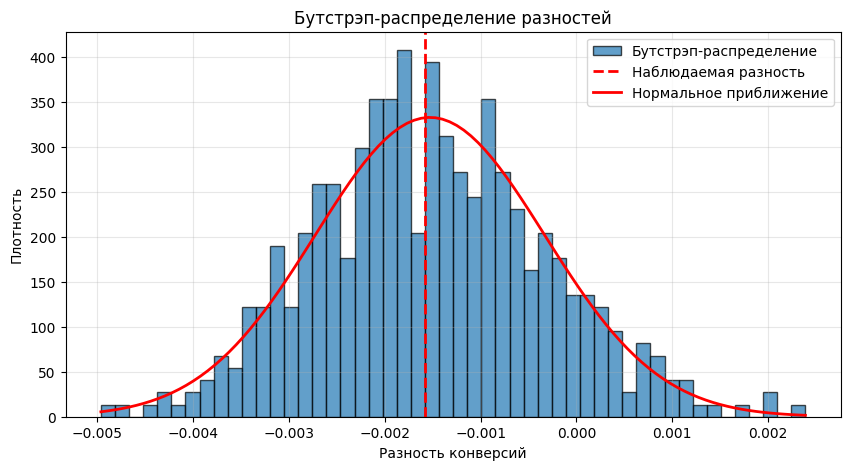

In [ ]:
plt.figure(figsize=(10, 5))

plt.hist(
    p_diffs,
    bins=50,
    alpha=0.7,
    edgecolor='black',
    density=True,
    label='Бутстрэп-распределение')

plt.axvline(
    observed_diff,
    color='red',
    linestyle='--',
    linewidth=2,
    label='Наблюдаемая разность')

x = np.linspace(p_diffs.min(), p_diffs.max(), 100)


plt.plot(
    x,
    norm.pdf(x, p_diffs.mean(), p_diffs.std()),
    'r-',
    linewidth=2,
    label='Нормальное приближение')

plt.xlabel('Разность конверсий')
plt.ylabel('Плотность')
plt.title('Бутстрэп-распределение разностей')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


95% доверительный интервал из бутстреппинга

In [ ]:
ci_bootstrap = np.percentile(p_diffs, [2.5, 97.5])
ci_bootstrap

array([-0.00373524,  0.00089111])

Бутстреп-анализ подтверждает, что разница в конверсии между группами статистически незначима — доверительный интервал разницы [-0.4041%, 0.1108%] включает ноль. Наблюдаемая разница (-0.122%) лежит близко к центру распределения, что также указывает на отсутствие эффекта от изменения.

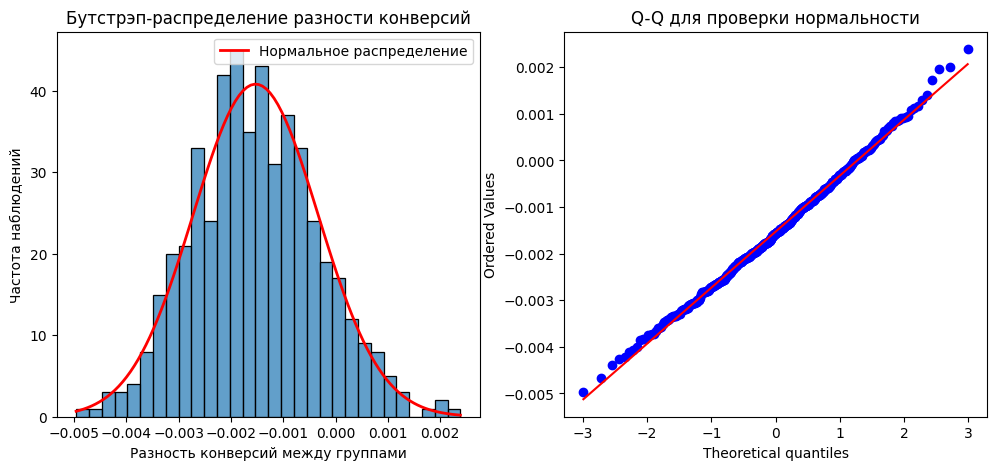

In [ ]:

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

sns.histplot(p_diffs, bins=30, kde=False, ax=ax1, alpha=0.7, edgecolor='black')
ax1.set_title('Бутстрэп-распределение разности конверсий')
ax1.set_xlabel('Разность конверсий между группами')
ax1.set_ylabel('Частота наблюдений')

# подгоняем распределение
mu, sigma = np.mean(p_diffs), np.std(p_diffs)
x_norm = np.linspace(p_diffs.min(), p_diffs.max(), 100)
y_norm = norm.pdf(x_norm, mu, sigma)

bin_width = (p_diffs.max() - p_diffs.min()) / 30
y_scaled = y_norm * len(p_diffs) * bin_width
ax1.plot(x_norm, y_scaled, 'r-', lw=2, label='Нормальное распределение')
ax1.legend()

probplot(p_diffs, dist="norm", plot=ax2)
ax2.set_title('Q-Q для проверки нормальности')

plt.show()

 Бутстреп-распределение разницы конверсий визуально близко к нормальному — точки на Q-Q графике в целом ложатся на прямую линию, а гистограмма хорошо описывается подобранной нормальной кривой. Это подтверждает, что для анализа разницы пропорций можно было использовать методы, основанные на нормальном приближении (например, z-тест).

Тест Шапиро-Уилка (подходит при n <= 5000)

In [ ]:
if len(p_diffs) <= 5000:
    shapiro_stat, shapiro_p = shapiro(p_diffs)
    print("Статистика: ", shapiro_stat)
    print("P-value: ", shapiro_p)

Статистика:  0.9973815358395584
P-value:  0.6198262259567582


Тест Д'Агостино-Пирсона

In [ ]:
k2_stat, k2_p = normaltest(p_diffs)
print("Статистика: ", k2_stat)
print("P-value: ", k2_p)

Статистика:  2.8429195571562724
P-value:  0.24136142536852795


Результаты тестов Шапиро-Уилка (p=0.62) и Д'Агостино-Пирсона (p=0.24) также показывают, что статистически значимых отклонений от нормального распределения не обнаружено